In [1]:
import pandas as pd
import numpy as np
from datetime import datetime
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn as sk

#Library to compute pair-wise Euclidean distance between all observations in the data
from sklearn import metrics

#Library to impute missing values with the KNN algorithm
from sklearn import impute 
%matplotlib inline
from sklearn.linear_model import LinearRegression
from scipy import stats

import warnings
warnings.filterwarnings("ignore")
import geopandas as gpd
import geopandas 
import folium
import geodatasets 
import json
import plotly.express as px
from scipy.stats import pearsonr

In [3]:
divvy = pd.read_csv('202301-divvy-tripdata.csv')
tnp = pd.read_csv('Transportation_Network_Providers_-_Trips_(2023-2024)_20251207.csv')

## Data quality check / cleaning / preparation 

Put code with comments. The comments should explain the code such that it can be easily understood. You may put text *(in a markdown cell)* before a large chunk of code to explain the overall purpose of the code, if it is not intuitive. **Put the name of the person / persons who contributed to each code chunk / set of code chunks.** An example is given below.

### Distribution of variables
*By Sylvia Sherwood*

In [7]:
def variable_distribution(df, top_n=5):
    rows = []

    for col in df.columns:
        series = df[col]
        dtype = series.dtype

        if series.dtype == 'object' or str(dtype) == "category" or series.nunique() < 20:
                value_counts = series.value_counts(dropna=False)
                top_levels = value_counts.head(top_n)

                rows.append({
                    "variable": col,
                    "type": "categorical",
                    "n_missing": series.isna().sum(),
                    "n_unique": series.nunique(),
                    "top_levels": dict(top_levels)
                })
        else:
            rows.append({
                "variable": col,
                "type": "continuous",
                "n_missing": series.isna().sum(),
                "mean": series.mean(),
                "std": series.std(),
                "min": series.min(),
                "25%": series.quantile(0.25),
                "50%": series.median(),
                "75%": series.quantile(0.75),
                "max": series.max(),
            })

    return pd.DataFrame(rows)

# divvy data distribution 
print(variable_distribution(divvy, top_n=5).to_string())
(variable_distribution(tnp, top_n=5))


# 


              variable         type  n_missing  n_unique                                                                                                                                           top_levels       mean       std        min        25%        50%        75%        max
0              ride_id  categorical          0  190301.0                                  {'F96D5A74A3E41399': 1, 'C02810DB3E08458A': 1, '3565941571215539': 1, 'E735834191455810': 1, '73E8358771C79621': 1}        NaN       NaN        NaN        NaN        NaN        NaN        NaN
1        rideable_type  categorical          0       3.0                                                                                 {'electric_bike': 98269, 'classic_bike': 90294, 'docked_bike': 1738}        NaN       NaN        NaN        NaN        NaN        NaN        NaN
2           started_at  categorical          0  178872.0                   {'2023-01-11 17:42:46': 5, '2023-01-16 15:39:56': 4, '2023-01-10 17:08:18': 4, 

,variable,type,n_missing,n_unique,top_levels,mean,std,min,25%,50%,75%,max
0,Trip ID,categorical,0,126302.0,{'d056f64eebc0b3d338850625c9ffca529b54aa56': 1...,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Trip Start Timestamp,categorical,0,285.0,"{'01/14/2023 06:45:00 PM': 1152, '01/14/2023 0...",NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Trip End Timestamp,categorical,0,288.0,"{'01/14/2023 07:00:00 PM': 1214, '01/14/2023 0...",NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Trip Seconds,categorical,0,2529.0,"{'896': 188, '904': 172, '908': 171, '414': 16...",NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,Trip Miles,continuous,0,NaN,NaN,4.073031,4.053304,0.000000,1.400000,2.700000,5.000000,40.100000
5,Percent Time Chicago,categorical,0,4.0,"{'100%': 126251, '99%': 47, '0%': 3, '97%': 1}",NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,Percent Distance Chicago,categorical,0,4.0,"{'100%': 126251, '99%': 47, '0%': 3, '97%': 1}",NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,Pickup Community Area,continuous,0,NaN,NaN,25.229743,19.431742,1.000000,8.000000,24.000000,33.000000,77.000000
8,Dropoff Community Area,continuous,0,NaN,NaN,25.487166,19.670896,1.000000,8.000000,24.000000,33.000000,77.000000
9,Fare,categorical,43,50.0,"{'$7.5': 30882, '$10': 27401, '$12.5': 22686, ...",NaN,NaN,NaN,NaN,NaN,NaN,NaN


### Data cleaning
*By Sankaranarayanan Balasubramanian & Fiona Fe*

In [55]:
divvy['started_at'] = pd.to_datetime(divvy['started_at'])
divvy['ended_at'] = pd.to_datetime(divvy['ended_at'])

In [ ]:

# Helper function to clean currency columns
def clean_currency(column):
    return pd.to_numeric(column.astype(str).str.replace('$', '').str.replace(',', '').str.strip(), errors='coerce').fillna(0.0)

# Process TNP
tnp['Trip Start Timestamp'] = pd.to_datetime(tnp['Trip Start Timestamp'])
tnp_jan = tnp[tnp['Trip Start Timestamp'].dt.month == 1].copy()

# Clean object-type numeric columns to avoid the TypeError
tnp_jan['Fare'] = clean_currency(tnp_jan['Fare'])
tnp_jan['Tip'] = clean_currency(tnp_jan['Tip'])
tnp_jan['Additional Charges'] = clean_currency(tnp_jan['Additional Charges'])
tnp_jan['Trip Miles'] = pd.to_numeric(tnp_jan['Trip Miles'], errors='coerce').fillna(0)
tnp_jan['Trip Seconds'] = pd.to_numeric(tnp_jan['Trip Seconds'], errors='coerce').fillna(0)

# Process Divvy 
divvy['started_at'] = pd.to_datetime(divvy['started_at'])
divvy['ended_at'] = pd.to_datetime(divvy['ended_at'])


### Data preparation
*By Ryu Kimiko*


In [51]:
######---------------Creating new variables----------------#########
divvy['duration_mins'] = (divvy['ended_at'] - divvy['started_at']).dt.total_seconds() / 60

conditions = [
    (tnp['Pickup Community Area'] <= 22),
    (tnp['Pickup Community Area'] <= 31) & (tnp['Pickup Community Area'] > 22),
    (tnp['Pickup Community Area'] <= 33) & (tnp['Pickup Community Area'] > 31),
    (tnp['Pickup Community Area'] <= 75) & (tnp['Pickup Community Area'] > 33),
    
]

# Define the corresponding string values for each condition
values = ['North Side', 'West Side', 'Central', 'South Side']

# Create a new column 'category' using np.select
# The 'default' parameter handles values not meeting any condition (e.g., <= 40)
tnp['region'] = np.select(conditions, values, default='North Side')

tnp['Trip Seconds'] = pd.to_numeric(tnp['Trip Seconds'].astype(str).str.replace(',', ''), errors='coerce')
tnp = tnp.dropna(subset=['Trip Seconds'])
tnp['tnp_min'] = (tnp['Trip Seconds'] // 60).astype('int64')
divvy['min'] = ((divvy['ended_at'] - divvy['started_at']).dt.total_seconds() // 60).astype('int64')

In [20]:
######-----Standardizing the dataset ----------------------#########

#### Daily Aggregation
# Aggregate TNP metrics by date
tnp_daily = tnp_jan.groupby(tnp_jan['Trip Start Timestamp'].dt.date).agg(
    tnp_rides=('Trip ID', 'size'),
    avg_tnp_fare=('Fare', 'mean'),
    avg_tnp_tip=('Tip', 'mean'),
    avg_tnp_miles=('Trip Miles', 'mean'),
    avg_tnp_seconds=('Trip Seconds', 'mean'),
    avg_tnp_charges=('Additional Charges', 'mean')
).reset_index().rename(columns={'Trip Start Timestamp': 'date'})

# Aggregate Divvy metrics by date
divvy_daily = divvy.groupby(divvy['started_at'].dt.date).agg(
    divvy_rides=('ride_id', 'size'),
    avg_divvy_duration_min=('duration_mins', 'mean'),
    casual_rides=('member_casual', lambda x: (x == 'casual').sum()),
    member_rides=('member_casual', lambda x: (x == 'member').sum())
).reset_index().rename(columns={'started_at': 'date'})

# Aggregate Divvy metrics by date
divvy_daily = divvy.groupby(divvy['started_at'].dt.date).agg(
    divvy_rides=('ride_id', 'size'),
    avg_divvy_duration_min=('duration_mins', 'mean'),
    casual_rides=('member_casual', lambda x: (x == 'casual').sum()),
    member_rides=('member_casual', lambda x: (x == 'member').sum())
).reset_index().rename(columns={'started_at': 'date'})

# 4. Merge dataframes
final_df = pd.merge(divvy_daily, tnp_daily, on='date', how='inner')
corr_matrix = final_df.drop(columns=['date']).corr()

In [13]:
#### Hourly Aggregation
tnp['start_time'] = pd.to_datetime(tnp['Trip Start Timestamp'])
tnp_jan = tnp[tnp['start_time'].dt.month == 1].copy()
tnp_jan['hour_bin'] = tnp_jan['start_time'].dt.floor('H')

# Clean object-type numeric columns to avoid the TypeError
tnp_jan['Fare'] = clean_currency(tnp_jan['Fare'])
tnp_jan['Tip'] = clean_currency(tnp_jan['Tip'])
tnp_jan['Additional Charges'] = clean_currency(tnp_jan['Additional Charges'])
tnp_jan['Trip Miles'] = pd.to_numeric(tnp_jan['Trip Miles'], errors='coerce').fillna(0)
tnp_jan['Trip Seconds'] = pd.to_numeric(tnp_jan['Trip Seconds'], errors='coerce').fillna(0)

tnp_hourly = tnp_jan.groupby('hour_bin').agg(
    tnp_ride_count=('Trip ID', 'size'),
    avg_tnp_fare=('Fare', 'mean'),
    avg_tnp_miles=('Trip Miles', 'mean'),
    avg_tnp_seconds=('Trip Seconds', 'mean'),
    avg_tnp_tips=('Tip', 'mean')
).reset_index()

# 3. Hourly Divvy Aggregation (Jan 2023)
divvy['start_time'] = pd.to_datetime(divvy['started_at'])
divvy['ended_at'] = pd.to_datetime(divvy['ended_at'])
divvy['hour_bin'] = divvy['start_time'].dt.floor('H')
divvy['duration_mins'] = (divvy['ended_at'] - divvy['start_time']).dt.total_seconds() / 60

divvy_hourly = divvy.groupby('hour_bin').agg(
    divvy_ride_count=('ride_id', 'size'),
    avg_divvy_duration=('duration_mins', 'mean'),
    divvy_casual_perc=('member_casual', lambda x: (x == 'casual').mean())
).reset_index()

# 4. Merging on Hour Timestamp
merged_hourly = pd.merge(divvy_hourly, tnp_hourly, on='hour_bin', how='inner')

## Exploratory data analysis

Put code with comments. The comments should explain the code such that it can be easily understood. You may put text *(in a markdown cell)* before a large chunk of code to explain the overall purpose of the code, if it is not intuitive. **Put the name of the person / persons who contributed to each code chunk / set of code chunks.**

### Analysis 1
*By \<Name of person doing the analysis>*

### Analysis 2
*By Alexa*

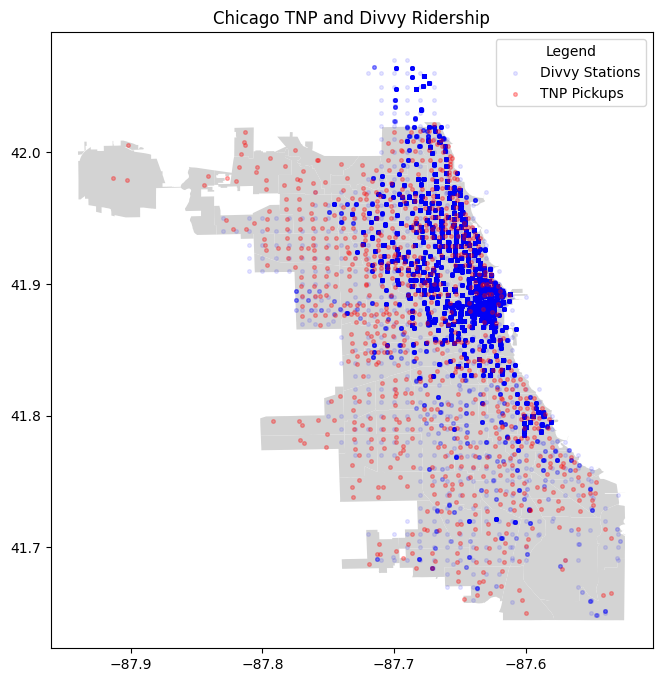

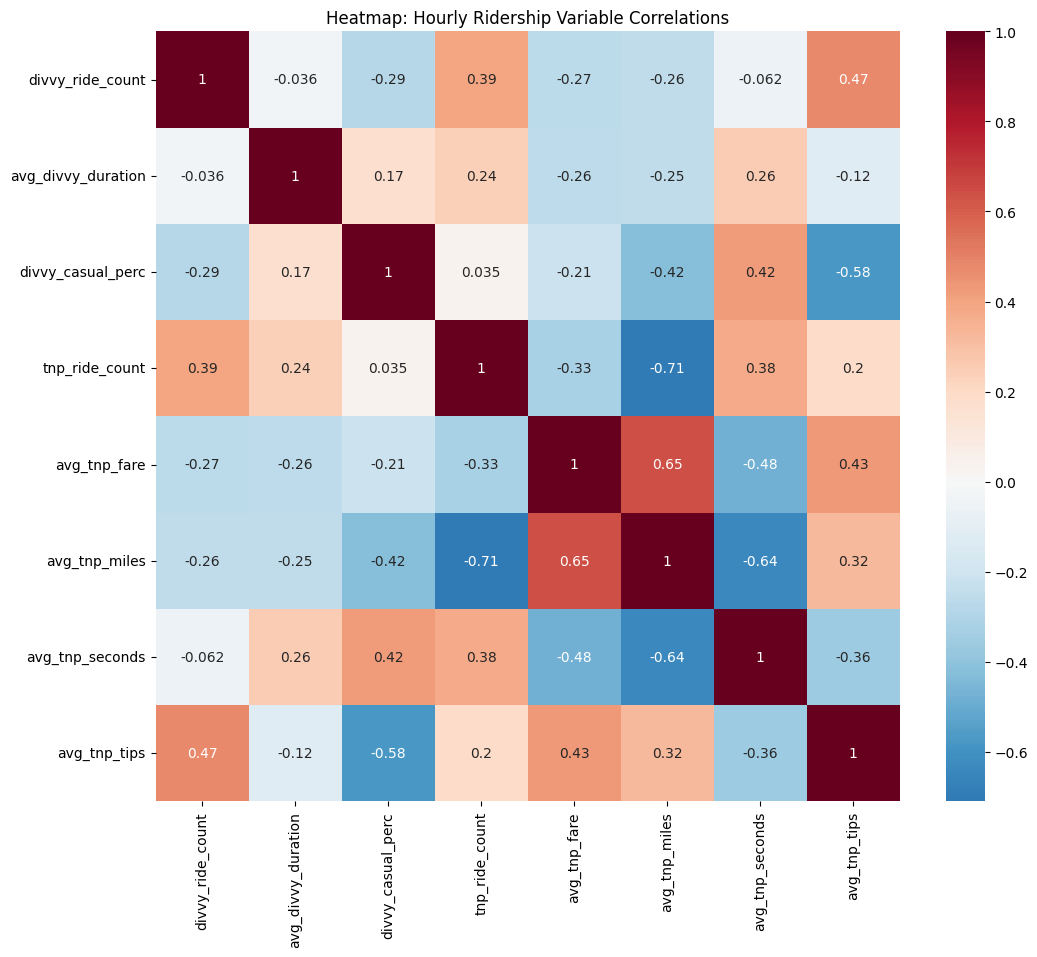

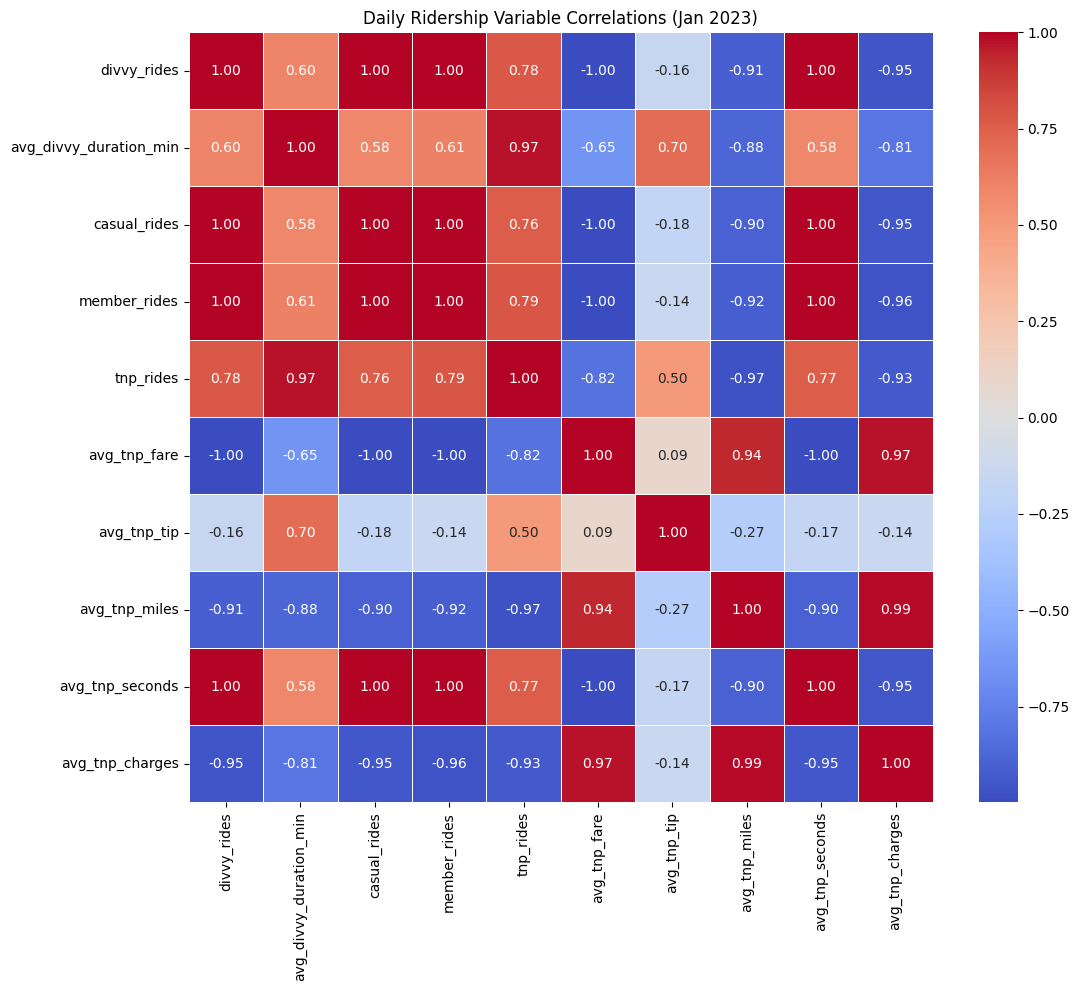

r  = 0.39267568550608956


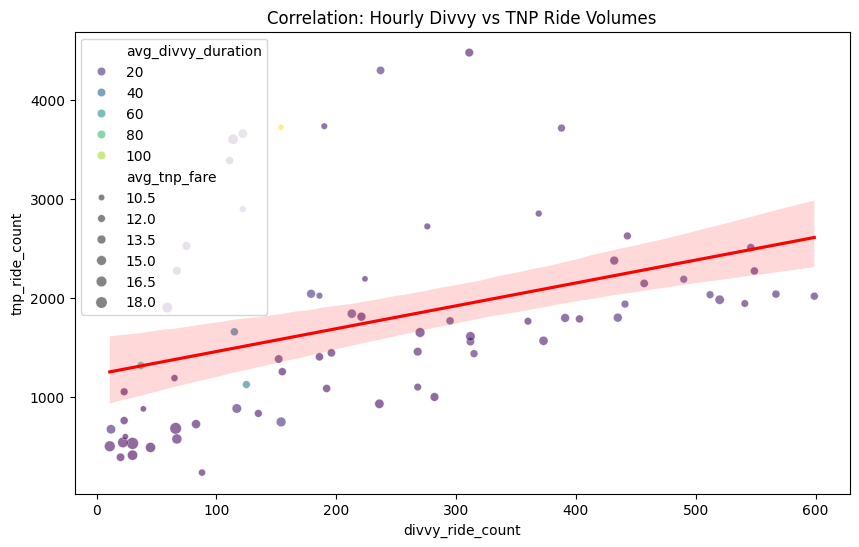

In [24]:
# *** geoplotting ***
chi = gpd.read_file('geo_export_c5010bdc-6062-4b24-9554-b85a53f7b455.shp') # shapefile for boundaries
# sets of points
unique_lat_long_df = divvy.drop_duplicates(subset=['start_lat', 'start_lng'])
gdf_points1 = gpd.GeoDataFrame(unique_lat_long_df, geometry=gpd.points_from_xy(unique_lat_long_df.start_lng, unique_lat_long_df.start_lat)) # divvy stations
unique_lat_long_df2 = tnp.drop_duplicates(subset=['Pickup Centroid Latitude', 'Pickup Centroid Longitude'])
gdf_points2 = gpd.GeoDataFrame(unique_lat_long_df2, geometry=gpd.points_from_xy(unique_lat_long_df2['Pickup Centroid Longitude'], unique_lat_long_df2['Pickup Centroid Latitude'])) # tnp pickups
# Adding the tnp pickups to the plot
fig, ax = plt.subplots(figsize=(10, 8))
chi.plot(column = 'area_num_1', ax=ax, color = 'lightgray')
gdf_points1.plot(ax=ax, marker='o', markersize=7, color='blue', alpha=0.1, label = 'Divvy Stations')
gdf_points2.plot(ax=ax, marker='o', markersize=7, color='red', alpha=0.3, label = 'TNP Pickups')
ax.legend(title="Legend")
plt.title('Chicago TNP and Divvy Ridership');

 # *** Correlation Heatmap (hourly agg) ***
plt.figure(figsize=(12, 10))
sns.heatmap(merged_hourly.drop(columns=['hour_bin']).corr(), annot=True, cmap='RdBu_r', center=0)
plt.savefig('hourly_heatmap.png')
plt.title('Heatmap: Hourly Ridership Variable Correlations')

 # *** Correlation Heatmap (daily agg) ***
plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Daily Ridership Variable Correlations (Jan 2023)')
plt.show()

# *** Scatter Plot/lm plot ***
plt.figure(figsize=(10, 6))
sns.scatterplot(data=merged_hourly, x='divvy_ride_count', y='tnp_ride_count', 
                size='avg_tnp_fare', hue='avg_divvy_duration', palette='viridis', alpha=0.6)
sns.regplot(data=merged_hourly, x='divvy_ride_count', y='tnp_ride_count', scatter=False, color='red')
plt.title('Correlation: Hourly Divvy vs TNP Ride Volumes')
plt.savefig('hourly_scatter_populated.png')
correlation, _ = pearsonr(merged_hourly['divvy_ride_count'], merged_hourly['tnp_ride_count'])
print(f'r  = {correlation}')


Text(0.5, 1.0, 'Mode of Travel to Work: Driving Alone')

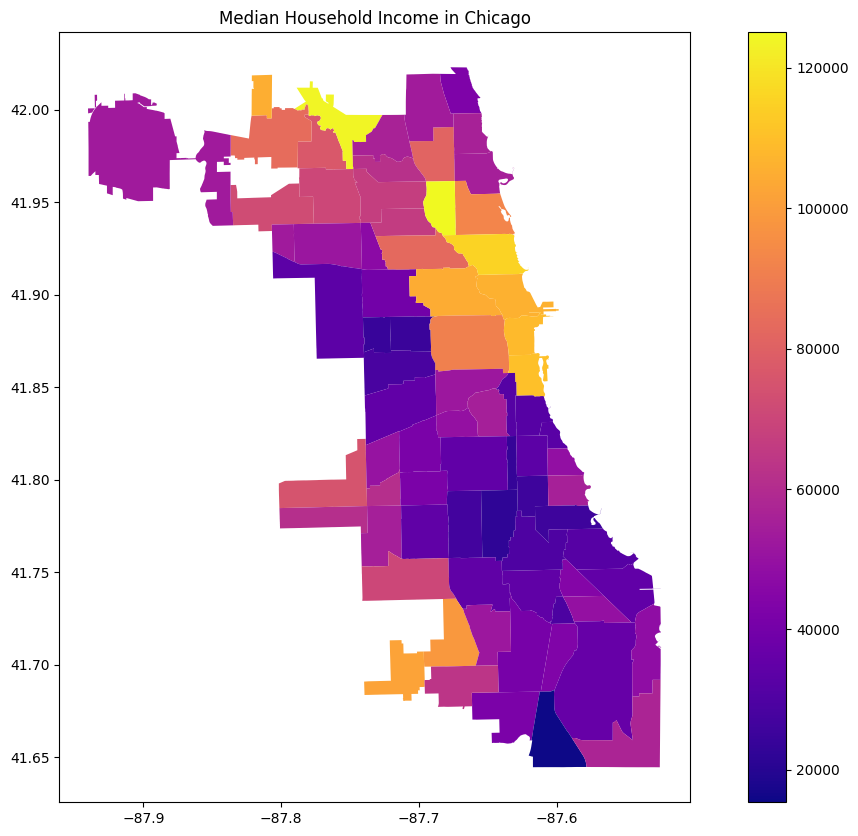

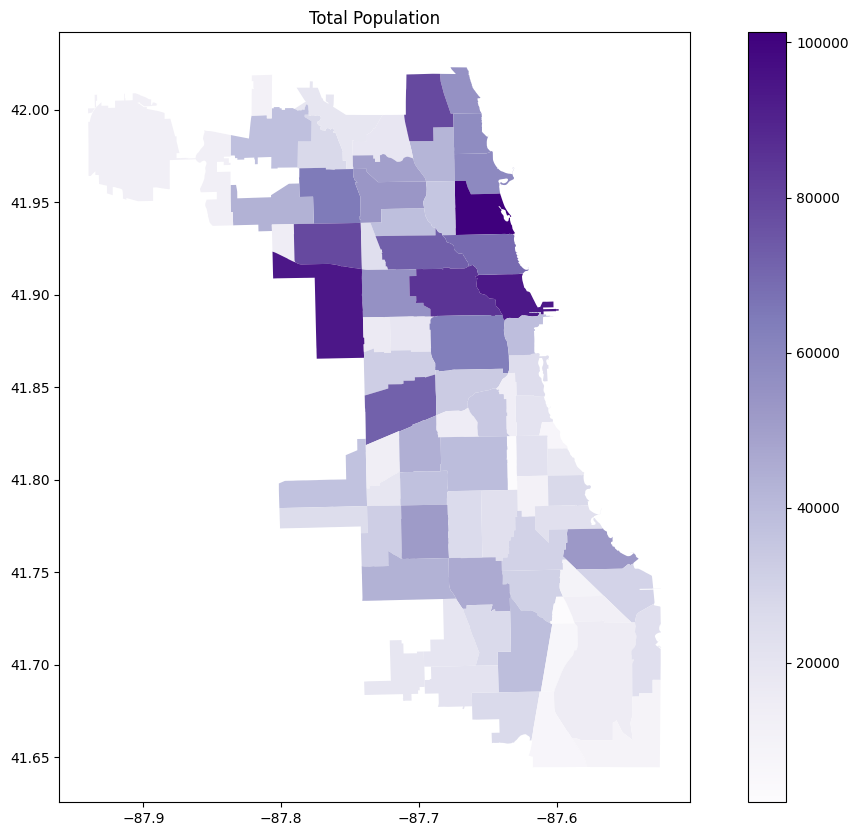

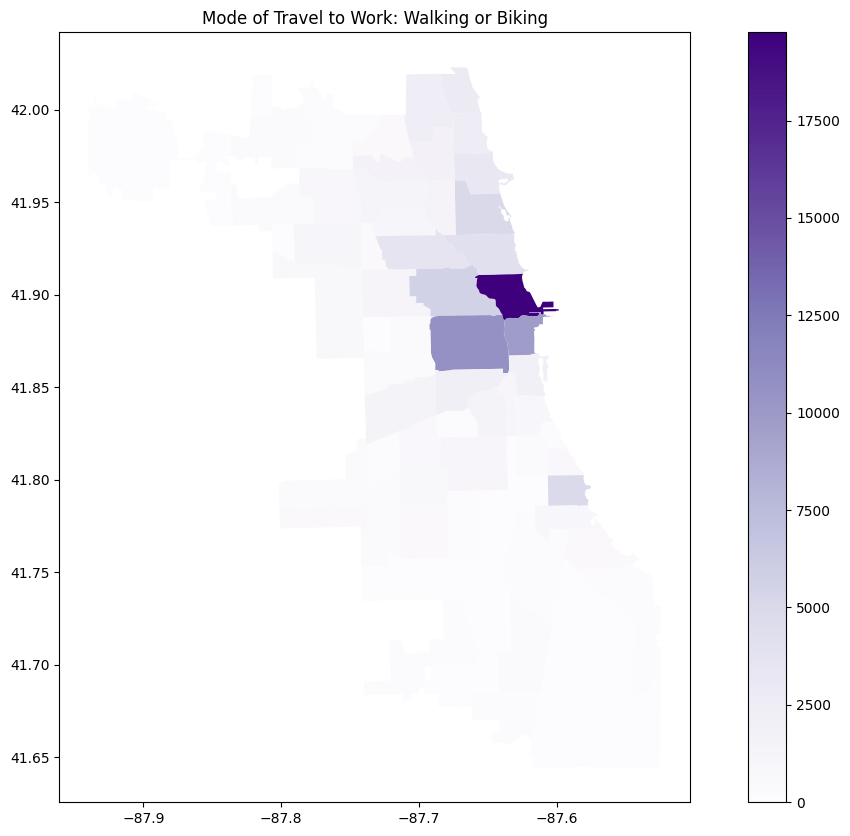

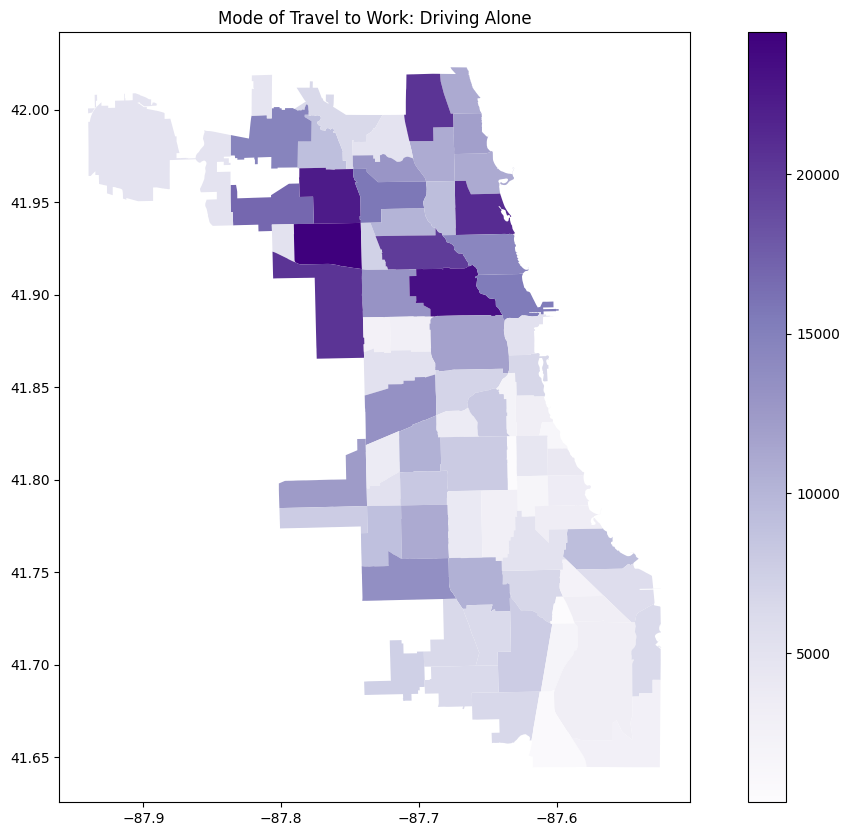

In [ ]:
# *** choropleths ***
chipop = gpd.read_file('Chicago_2020_sdoh.shp') # data 

# median household income
fig, ax = plt.subplots(figsize=(15, 10))
chipop.plot(column='MEDINC', ax=ax, legend=True, cmap='plasma') # using column median income 
plt.title('Median Household Income in Chicago')

# total population
fig, ax = plt.subplots(figsize=(15, 10))
chipop.plot(column='TOT_POP', ax=ax, legend=True, cmap='Purples') # using column total population
plt.title('Total Population')

# walk/bike to work
fig, ax = plt.subplots(figsize=(15, 10))
chipop.plot(column='WALK_BIKE', ax=ax, legend=True, cmap='Purples') # using column walk/bike (people who walk or bike to work)
plt.title('Mode of Travel to Work: Walking or Biking')

# drive alone to work
fig, ax = plt.subplots(figsize=(15, 10))
chipop.plot(column='DROVE_AL', ax=ax, legend=True, cmap='Purples') # using column drove alone (people who drive alone to work)
plt.title('Mode of Travel to Work: Driving Alone')

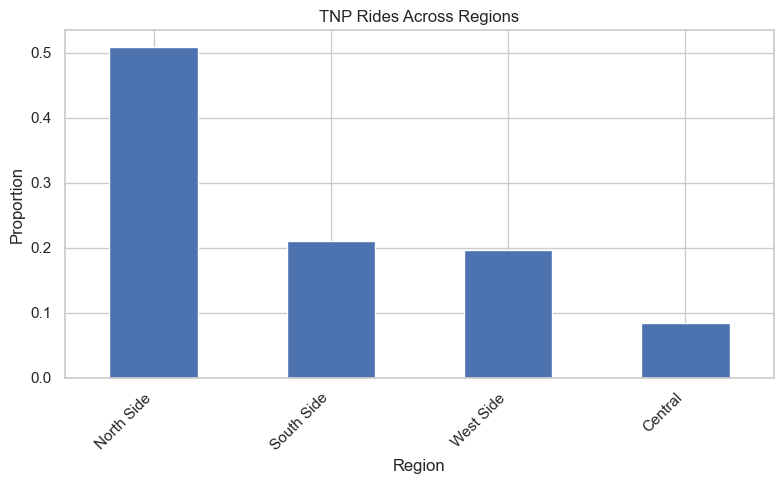

In [50]:
# rides across region
category_counts = tnp['region'].value_counts(normalize=True)
ax = category_counts.plot(kind='bar', figsize=(8, 5))

# Add labels and a title for clarity
ax.set_xlabel('Region')
ax.set_ylabel('Proportion')
ax.set_title('TNP Rides Across Regions')

# Rotate x-axis labels if needed for better readability
plt.xticks(rotation=45, ha='right')

# Display the plot
plt.tight_layout() # Adjust layout to prevent labels from overlapping
plt.show()

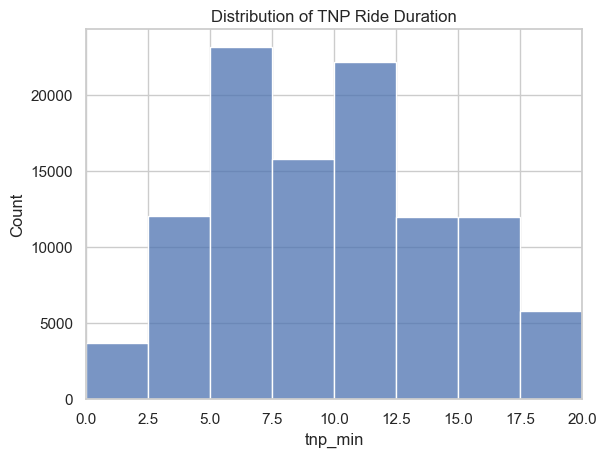

median = 11.0
mean = 12.369139047679372
Mean duration (filtered): 9.26
Median duration (filtered): 7.00
Percentage of trips within 0-60 mins: 95.9%


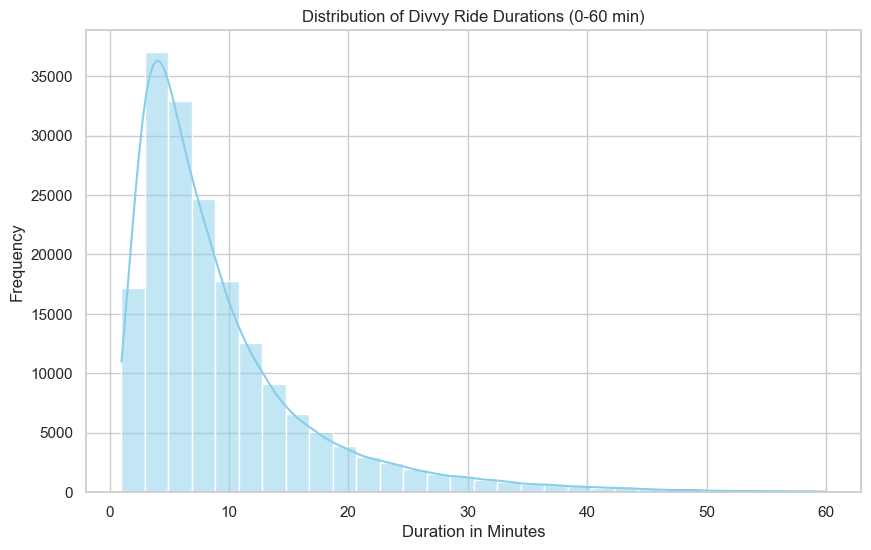

In [52]:
# *** histograms ***

# tnp ride duration
sns.histplot(data=tnp, x = 'tnp_min', bins=24)
# Adjust x-axis limits
plt.xlim(0, 20)
plt.title('Distribution of TNP Ride Duration')
plt.show()
print(f'median = {tnp['tnp_min'].median()}')
print(f'mean = {tnp['tnp_min'].mean()}')

# divvy ride duration
filtered_df = divvy[(divvy['min'] > 0) & (divvy['min'] <= 60)]
# Create the histogram
sns.set_theme(style="whitegrid")
plt.figure(figsize=(10, 6))
sns.histplot(filtered_df['min'], bins=30, kde=True, color='skyblue')
# Labels and title
plt.title('Distribution of Divvy Ride Durations (0-60 min)')
plt.xlabel('Duration in Minutes')
plt.ylabel('Frequency')
# Output some stats for context in response
print(f"Mean duration (filtered): {filtered_df['min'].mean():.2f}")
print(f"Median duration (filtered): {filtered_df['min'].median():.2f}")
print(f"Percentage of trips within 0-60 mins: {(len(filtered_df)/len(divvy))*100:.1f}%")


### Analysis 3
*By \<Name of person doing the analysis>*

### Analysis 4
*By \<Name of person doing the analysis>*